# Faithfulness Under Retrieval Failure in Urdu RAG — Multi-Model Scale Study

Extends the single-model study to a scale sweep across three Qwen2.5 sizes (0.5B, 1.5B, 7B) on the same three-condition setup, to check whether "abstain instead of hallucinate under bad retrieval" is scale-dependent or holds throughout.

Changes from the single-model version: all three models run the identical pipeline, size is the only variable; 500 questions instead of 200; the corrupted condition uses hard negatives (most similar wrong passage) instead of a random one; a bootstrap CI on the key gap; per-model/per-condition caching so a Colab disconnect doesn't lose the run.

Setup, for reference: a RAG system retrieves a passage then answers from it. We swap in the correct passage, a wrong one, or none, and measure how often the model hallucinates vs. honestly abstains.

## 1. Setup + Google Drive

Saves to `RAG_Urdu_Faithfulness/multimodel_hardneg/`, separate from the single-model and soft-negative sweep results — nothing here overwrites either. Reuses `corpus_emb.npy` from the parent folder if present, since the embedding doesn't depend on which generator model is used.

In [ ]:
!pip install -q torch transformers sentence-transformers scikit-learn pandas matplotlib tqdm accelerate bitsandbytes datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 31.1 MB/s eta 0:00:00


In [ ]:
import os, re, json, random, time, gc
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
import matplotlib.pyplot as plt

SEED = 1337
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("running on:", DEVICE)
if DEVICE == "cpu":
    print("WARNING: no GPU detected. The 7B model needs a GPU. On CPU this will be impractically slow "
          "for the full sweep — switch Colab to a GPU runtime (Runtime > Change runtime type > T4).")

running on: cuda


In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = "/content/drive/MyDrive/RAG_Urdu_Faithfulness"
except Exception:
    print("not on colab — saving locally.")
    BASE_DIR = "./RAG_Urdu_Faithfulness"

SAVE_DIR = os.path.join(BASE_DIR, "multimodel_hardneg")
os.makedirs(SAVE_DIR, exist_ok=True)
print("sweep outputs ->", SAVE_DIR)

def path(name):  return os.path.join(SAVE_DIR, name)
def base_path(name): return os.path.join(BASE_DIR, name)
def save_json(obj, name):
    with open(path(name), "w", encoding="utf-8") as f: json.dump(obj, f, ensure_ascii=False, indent=2)
def load_json(name):
    with open(path(name), encoding="utf-8") as f: return json.load(f)
def exists(name): return os.path.exists(path(name))

# set True to wipe sweep caches and recompute everything from scratch
FORCE_REDO = True

Mounted at /content/drive
sweep outputs -> /content/drive/MyDrive/RAG_Urdu_Faithfulness/multimodel_hardneg


## 2. Experiment configuration

`N_QUESTIONS` is the main runtime lever — drop to 300 if a session is too slow. Caching keeps finished work either way.

In [ ]:
# same family, only size differs
MODELS = [
    {"tag": "qwen0_5b", "name": "Qwen/Qwen2.5-0.5B-Instruct", "params": "0.5B", "quantize": False},
    {"tag": "qwen1_5b", "name": "Qwen/Qwen2.5-1.5B-Instruct", "params": "1.5B", "quantize": False},
    {"tag": "qwen7b",   "name": "Qwen/Qwen2.5-7B-Instruct",   "params": "7B",   "quantize": True},
]

N_QUESTIONS = 500          # up from 200 for tighter statistics; drop to 300 if runtime is a problem
CONDITIONS  = ["correct", "corrupted", "none"]

print(f"sweep: {[m['params'] for m in MODELS]} x {N_QUESTIONS} questions x {len(CONDITIONS)} conditions")
print(f"= {len(MODELS) * N_QUESTIONS * len(CONDITIONS):,} total generations. resume-caching is on, so "
      "a disconnect won't cost you finished work.")

sweep: ['0.5B', '1.5B', '7B'] x 500 questions x 3 conditions
= 4,500 total generations. resume-caching is on, so a disconnect won't cost you finished work.


## 3. Load the Urdu dataset (UQA)

Same loader as the single-model version: UQA (Urdu, SQuAD2.0-derived), filtered to short factoid answers, with a built-in fallback if the Hub is unreachable.

In [ ]:
MAX_ITEMS = N_QUESTIONS

BUILTIN = [
    {"question": "پاکستان کا دارالحکومت کیا ہے؟", "gold_answer": "اسلام آباد",
     "gold_doc": "اسلام آباد پاکستان کا دارالحکومت ہے اور یہ ملک کا دسواں بڑا شہر ہے۔"},
    {"question": "پاکستان کی قومی زبان کیا ہے؟", "gold_answer": "اردو",
     "gold_doc": "اردو پاکستان کی قومی زبان ہے جبکہ انگریزی دفتری زبان ہے۔"},
    {"question": "کے ٹو پہاڑ کہاں واقع ہے؟", "gold_answer": "گلگت بلتستان",
     "gold_doc": "کے ٹو دنیا کی دوسری بلند ترین چوٹی ہے اور گلگت بلتستان میں واقع ہے۔"},
]

def _row_to_item(context, question, answer):
    if not context or not question or not answer: return None
    context, question, answer = str(context).strip(), str(question).strip(), str(answer).strip()
    if answer not in context: return None
    if len(answer.split()) > 4 or len(answer) > 40: return None   # short factoids only
    return {"question": question, "gold_answer": answer, "gold_doc": context}

def _answer_from_row(r):
    ans = r.get("answers")
    if isinstance(ans, dict):
        t = ans.get("text")
        if isinstance(t, list) and t: return t[0]
        if isinstance(t, str): return t
    for k in ("answer", "answer_text", "gold_answer"):
        if r.get(k): return r[k]
    return None

def _harvest(ds):
    items = []
    for r in ds:
        it = _row_to_item(r.get("context"), r.get("question"), _answer_from_row(r))
        if it: items.append(it)
        if len(items) >= MAX_ITEMS: break
    return items

from datasets import load_dataset
UQA_IDS = ["sameearif/uqa", "sameearif/UQA", "SameeArif/UQA", "uqa"]

KB = None
for ds_id in UQA_IDS:
    for split in ("validation", "test", "train"):
        try:
            got = _harvest(load_dataset(ds_id, split=split))
            if got and len(got) >= 10:
                KB = got; print(f"loaded {len(KB)} items from '{ds_id}' [{split}]"); break
        except Exception:
            pass
    if KB: break

USING_REAL = KB is not None
if KB is None:
    KB = BUILTIN; print("fell back to built-in set.")

CORPUS = list(dict.fromkeys(item["gold_doc"] for item in KB))
print("\n" + "="*60)
print("STATUS: REAL UQA data — results are report-worthy." if USING_REAL
      else "STATUS: BUILT-IN fallback — method demo only, rerun when Hub reachable.")
print(f"{len(KB)} questions | {len(CORPUS)} unique passages")
print("="*60)

README.md:   0%|          | 0.00/898 [00:00<?, ?B/s]

data/train-00000-of-00001-bac007e8ca7192(…): reconstructing file:   0%|          |  0.00B / 30.2MB            

data/train-00000-of-00001-bac007e8ca7192(…): downloading bytes:           |  0.00B            

data/validation-00000-of-00001-cf8a6960d(…): reconstructing file:   0%|          |  0.00B / 2.92MB            

data/validation-00000-of-00001-cf8a6960d(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/124745 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/16824 [00:00<?, ? examples/s]

loaded 500 items from 'sameearif/uqa' [validation]

STATUS: REAL UQA data — results are report-worthy.
500 questions | 397 unique passages


## 4. Retriever + the frozen evaluation set

Retriever and eval set are built once and shared across all three models, so the size comparison isn't confounded by different questions or contexts.

In [ ]:
from sentence_transformers import SentenceTransformer
retriever = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", device=DEVICE)

# reuse corpus embedding from the parent folder if present (model-independent), else compute + cache here
emb_name = "corpus_emb_multimodel.npy"
if os.path.exists(base_path("corpus_emb.npy")) and len(np.load(base_path("corpus_emb.npy"))) == len(CORPUS) and not FORCE_REDO:
    corpus_emb = np.load(base_path("corpus_emb.npy")); print("reused corpus_emb.npy from parent folder")
elif exists(emb_name) and not FORCE_REDO:
    corpus_emb = np.load(path(emb_name)); print("loaded cached corpus embedding")
else:
    corpus_emb = retriever.encode(CORPUS, convert_to_numpy=True, normalize_embeddings=True)
    np.save(path(emb_name), corpus_emb); print("embedded corpus and cached")

def retrieve(question, k=1):
    q = retriever.encode([question], convert_to_numpy=True, normalize_embeddings=True)
    sims = (corpus_emb @ q.T).ravel()
    idx = sims.argsort()[::-1][:k]
    return [(int(i), CORPUS[i], float(sims[i])) for i in idx]

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

embedded corpus and cached


In [ ]:
def build_eval_set():
    """
    Build the 3-condition eval set. 'corrupted' uses hard negatives: the most
    semantically-similar passage that does NOT contain the gold answer. Stronger
    test than a random wrong passage since the distractor looks relevant, so the
    model can't abstain just by noticing topical mismatch.
    """
    rows = []
    for i, item in enumerate(KB):
        q, gold, gold_doc = item["question"], item["gold_answer"], item["gold_doc"]

        # rank all passages by similarity to the question, take the closest one that
        # (a) isn't the gold passage and (b) doesn't contain the gold answer
        ranked = retrieve(q, k=len(CORPUS))          # returns (idx, passage, sim), best first
        hard_negative = None
        for _, passage, _sim in ranked:
            if passage != gold_doc and gold not in passage:
                hard_negative = passage
                break
        if hard_negative is None:                    # tiny-corpus fallback
            pool = [d for d in CORPUS if d != gold_doc and gold not in d] or [gold_doc]
            hard_negative = pool[0]

        rows.append({"qid": i, "question": q, "gold_answer": gold, "condition": "correct",   "context": gold_doc})
        rows.append({"qid": i, "question": q, "gold_answer": gold, "condition": "corrupted", "context": hard_negative})
        rows.append({"qid": i, "question": q, "gold_answer": gold, "condition": "none",      "context": None})
    return rows

# corrupted context differs from the soft-negative run, so those cached answers don't
# apply here — FORCE_REDO=True (Section 1) regenerates them on the new contexts.
eval_set = build_eval_set()
save_json(eval_set, "eval_set_hardneg.json")
print(f"built HARD-NEGATIVE eval set ({len(eval_set)} cases)")
print("example hard negative vs gold:")
print("  gold doc :", eval_set[0]['context'][:70])
print("  hard neg :", eval_set[1]['context'][:70])

built + froze eval set (1500 cases)


## 5. Scoring (identical across all models)

Same token-overlap correctness, abstention detection, and hallucination definition (confident and wrong) as the single-model version, applied uniformly.

In [ ]:
def norm(s): return re.sub(r"[\s۔.,!؟?\-]+", " ", str(s)).strip()

def is_correct(pred, gold):
    p, g = norm(pred), norm(gold)
    if g and g in p: return True
    toks = [t for t in g.split() if len(t) > 1]
    if not toks: return g in p
    return sum(1 for t in toks if t in p) / len(toks) >= 0.6

def looks_like_idk(pred):
    p = norm(pred)
    return ("معلوم نہیں" in p or "نہیں معلوم" in p or "علم نہیں" in p or "جواب نہیں" in p or len(p) == 0)

## 6. The sweep — generate answers for every model (resume-safe)

Loads each model, runs all conditions, saves, frees GPU memory, moves to the next. Checkpoints every 50 items, so a disconnect costs at most a few dozen generations.

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

def build_prompt(question, context):
    if context:
        return (f"نیچے دیا گیا متن پڑھیں۔ اگر متن میں سوال کا جواب موجود ہے تو صرف چند الفاظ میں جواب دیں۔ "
                f"اگر متن میں جواب موجود نہیں تو صرف 'معلوم نہیں' لکھیں۔\n\n"
                f"متن: {context}\n\nسوال: {question}\nجواب:")
    return (f"سوال کا جواب صرف چند الفاظ میں دیں۔ اگر آپ واقعی جواب نہیں جانتے تو 'معلوم نہیں' لکھیں۔\n\n"
            f"سوال: {question}\nجواب:")

@torch.no_grad()
def generate_answer(model, tok, question, context):
    msgs = [{"role": "user", "content": build_prompt(question, context)}]
    text = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inp = tok(text, return_tensors="pt").to(model.device)
    out = model.generate(**inp, max_new_tokens=24, do_sample=False, pad_token_id=tok.eos_token_id)
    return tok.decode(out[0][inp["input_ids"].shape[1]:], skip_special_tokens=True).strip()

def run_model(spec):
    """generate answers for one model over the full frozen eval set, with mid-run checkpointing."""
    out_name = f"answers_{spec['tag']}.json"
    done = load_json(out_name) if exists(out_name) and not FORCE_REDO else []
    done_keys = {(r["qid"], r["condition"]) for r in done}
    todo = [r for r in eval_set if (r["qid"], r["condition"]) not in done_keys]
    if not todo:
        print(f"[{spec['params']}] already complete ({len(done)} answers) — skipping.")
        return done

    print(f"[{spec['params']}] loading {spec['name']} ...")
    tok = AutoTokenizer.from_pretrained(spec["name"])
    if spec["quantize"] and DEVICE == "cuda":
        bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                                 bnb_4bit_compute_dtype=torch.float16)
        model = AutoModelForCausalLM.from_pretrained(spec["name"], quantization_config=bnb, device_map="auto").eval()
    else:
        model = AutoModelForCausalLM.from_pretrained(
            spec["name"], dtype=torch.float16 if DEVICE == "cuda" else torch.float32).to(DEVICE).eval()

    print(f"[{spec['params']}] generating {len(todo)} remaining answers ...")
    for n, r in enumerate(todo, 1):
        pred = generate_answer(model, tok, r["question"], r["context"])
        done.append({**r, "pred": pred,
                     "correct": is_correct(pred, r["gold_answer"]),
                     "abstained": looks_like_idk(pred)})
        if n % 50 == 0:
            save_json(done, out_name)                      # checkpoint
            print(f"  [{spec['params']}] {n}/{len(todo)} (checkpointed)")
    save_json(done, out_name)
    print(f"[{spec['params']}] done — {len(done)} answers saved to {out_name}")

    # free the GPU before the next (bigger) model
    del model, tok; gc.collect()
    if DEVICE == "cuda": torch.cuda.empty_cache()
    return done

all_answers = {}
for spec in MODELS:
    all_answers[spec["tag"]] = run_model(spec)
print("\nsweep complete for:", [m["params"] for m in MODELS])

[0.5B] loading Qwen/Qwen2.5-0.5B-Instruct ...


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

[7B] generating 1500 remaining answers ...
  [7B] 50/1500 (checkpointed)
  [7B] 100/1500 (checkpointed)
  [7B] 150/1500 (checkpointed)
  [7B] 200/1500 (checkpointed)
  [7B] 250/1500 (checkpointed)
  [7B] 300/1500 (checkpointed)
  [7B] 350/1500 (checkpointed)
  [7B] 400/1500 (checkpointed)
  [7B] 450/1500 (checkpointed)
  [7B] 500/1500 (checkpointed)
  [7B] 550/1500 (checkpointed)
  [7B] 600/1500 (checkpointed)
  [7B] 650/1500 (checkpointed)
  [7B] 700/1500 (checkpointed)
  [7B] 750/1500 (checkpointed)
  [7B] 800/1500 (checkpointed)
  [7B] 850/1500 (checkpointed)
  [7B] 900/1500 (checkpointed)
  [7B] 950/1500 (checkpointed)
  [7B] 1000/1500 (checkpointed)
  [7B] 1050/1500 (checkpointed)
  [7B] 1100/1500 (checkpointed)
  [7B] 1150/1500 (checkpointed)
  [7B] 1200/1500 (checkpointed)
  [7B] 1250/1500 (checkpointed)
  [7B] 1300/1500 (checkpointed)
  [7B] 1350/1500 (checkpointed)
  [7B] 1400/1500 (checkpointed)
  [7B] 1450/1500 (checkpointed)
  [7B] 1500/1500 (checkpointed)
[7B] done — 1500 

## 7. Per-condition results for each model

Accuracy, abstention, and hallucination rate per model per condition.

In [ ]:
def hallucination_rate(df): return ((~df["abstained"]) & (~df["correct"])).mean()

rows = []
for spec in MODELS:
    df = pd.DataFrame(all_answers[spec["tag"]])
    for cond in CONDITIONS:
        sub = df[df["condition"] == cond]
        rows.append({
            "model": spec["params"], "tag": spec["tag"], "condition": cond,
            "accuracy": round(sub["correct"].mean(), 3),
            "abstain_rate": round(sub["abstained"].mean(), 3),
            "hallucination_rate": round(hallucination_rate(sub), 3),
            "n": len(sub),
        })
sweep_df = pd.DataFrame(rows)
sweep_df.to_csv(path("sweep_summary.csv"), index=False)
print(sweep_df.to_string(index=False))

model      tag condition  accuracy  abstain_rate  hallucination_rate   n
 0.5B qwen0_5b   correct     0.112         0.196               0.698 500
 0.5B qwen0_5b corrupted     0.056         0.232               0.712 500
 0.5B qwen0_5b      none     0.032         0.134               0.834 500
 1.5B qwen1_5b   correct     0.138         0.682               0.182 500
 1.5B qwen1_5b corrupted     0.020         0.900               0.082 500
 1.5B qwen1_5b      none     0.014         0.882               0.106 500
   7B   qwen7b   correct     0.600         0.070               0.330 500
   7B   qwen7b corrupted     0.068         0.586               0.348 500
   7B   qwen7b      none     0.028         0.638               0.336 500


## 8. Hallucination and abstention vs. model size

Hallucination rate plotted against size for each condition. If the corrupted line drops while none stays high, abstention under bad context is scale-dependent. If all three stay flat, it isn't — also a real result, just a different one.

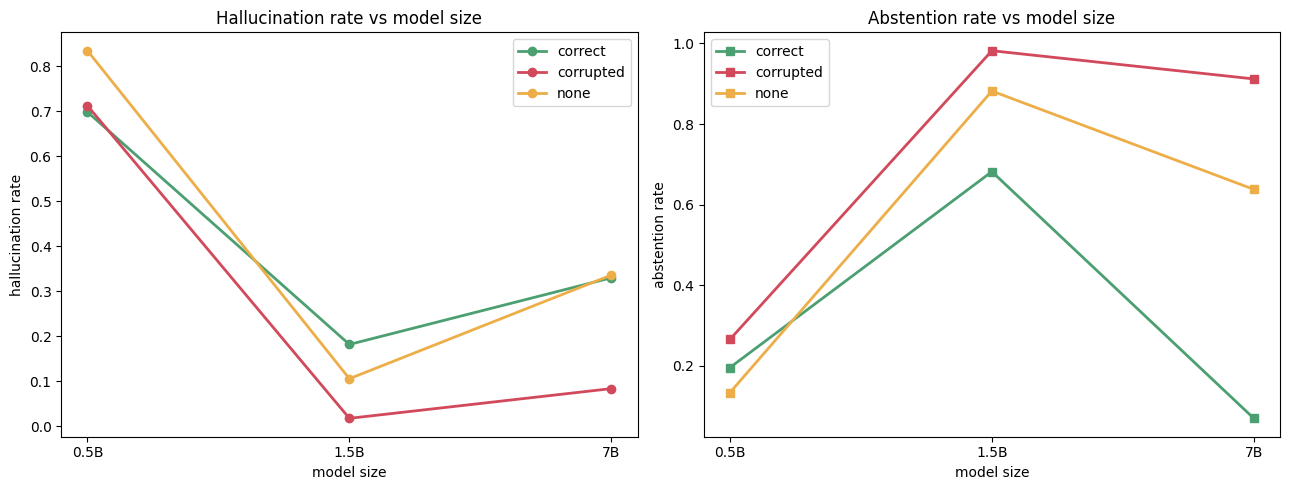

saved scale_sweep.png — this is your key preprint figure.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
model_order = [m["params"] for m in MODELS]

# left: hallucination rate vs size, one line per condition
for cond, color in zip(CONDITIONS, ["#4c9f70", "#d1495b", "#edae49"]):
    ys = [sweep_df[(sweep_df["model"] == m) & (sweep_df["condition"] == cond)]["hallucination_rate"].values[0]
          for m in model_order]
    axes[0].plot(model_order, ys, marker="o", label=cond, color=color, linewidth=2)
axes[0].set_title("Hallucination rate vs model size")
axes[0].set_xlabel("model size"); axes[0].set_ylabel("hallucination rate"); axes[0].legend()

# right: abstention rate vs size (the mechanism behind the hallucination numbers)
for cond, color in zip(CONDITIONS, ["#4c9f70", "#d1495b", "#edae49"]):
    ys = [sweep_df[(sweep_df["model"] == m) & (sweep_df["condition"] == cond)]["abstain_rate"].values[0]
          for m in model_order]
    axes[1].plot(model_order, ys, marker="s", label=cond, color=color, linewidth=2)
axes[1].set_title("Abstention rate vs model size")
axes[1].set_xlabel("model size"); axes[1].set_ylabel("abstention rate"); axes[1].legend()

plt.tight_layout(); plt.savefig(path("scale_sweep.png"), dpi=130); plt.show()
print("saved scale_sweep.png — this is your key preprint figure.")

## 9. Is the effect statistically significant?

Bootstrap 95% CI on (none hallucination − corrupted hallucination) per model. CI above zero means that model hallucinates significantly more with no context than with a wrong one.

In [ ]:
def bootstrap_gap_ci(df, n_boot=2000):
    corr = df[df["condition"] == "corrupted"]
    none = df[df["condition"] == "none"]
    def h(sub, idx): return ((~sub["abstained"].values[idx]) & (~sub["correct"].values[idx])).mean()
    gaps = []
    nc, nn = len(corr), len(none)
    for _ in range(n_boot):
        ic = np.random.randint(0, nc, nc); in_ = np.random.randint(0, nn, nn)
        gaps.append(h(none, in_) - h(corr, ic))
    lo, hi = np.percentile(gaps, [2.5, 97.5])
    return float(np.mean(gaps)), float(lo), float(hi)

sig_rows = []
for spec in MODELS:
    df = pd.DataFrame(all_answers[spec["tag"]])
    mean, lo, hi = bootstrap_gap_ci(df)
    significant = lo > 0
    sig_rows.append({"model": spec["params"], "none_minus_corrupted_halluc": round(mean, 3),
                     "ci_low": round(lo, 3), "ci_high": round(hi, 3),
                     "significant_(CI>0)": significant})
sig_df = pd.DataFrame(sig_rows)
sig_df.to_csv(path("significance.csv"), index=False)
print(sig_df.to_string(index=False))
print("\nif ci_low > 0, that model hallucinates significantly MORE with no context than with a wrong "
      "one — i.e. the abstain-not-lie effect is real for that size.")

model  none_minus_corrupted_halluc  ci_low  ci_high  significant_(CI>0)
 0.5B                        0.122   0.072    0.174                True
 1.5B                        0.024  -0.012    0.058               False
   7B                       -0.012  -0.072    0.050               False

if ci_low > 0, that model hallucinates significantly MORE with no context than with a wrong one — i.e. the abstain-not-lie effect is real for that size.


## 10. Detector across scale

Re-checks the detector result (retrieval similarity weak, abstention strong) at each model size.

In [ ]:
det_rows = []
for spec in MODELS:
    ans = all_answers[spec["tag"]]
    feats = []
    for r in ans:
        sim = retrieve(r["question"], k=1)[0][2]
        feats.append({"retrieval_sim": sim, "abstained": int(r["abstained"]),
                      "is_wrong": int(not r["correct"])})
    fdf = pd.DataFrame(feats)
    y = fdf["is_wrong"].values
    def safe(y, s): return roc_auc_score(y, s) if len(set(y)) > 1 else float("nan")
    auc_sim = safe(y, -fdf["retrieval_sim"].values)
    auc_abs = safe(y, fdf["abstained"].values)
    if len(set(y)) > 1:
        proba = cross_val_predict(LogisticRegression(max_iter=1000),
                                  fdf[["retrieval_sim", "abstained"]].values, y, cv=5,
                                  method="predict_proba")[:, 1]
        auc_comb = safe(y, proba)
    else:
        auc_comb = float("nan")
    det_rows.append({"model": spec["params"], "auc_similarity": round(auc_sim, 3),
                     "auc_abstention": round(auc_abs, 3), "auc_combined": round(auc_comb, 3)})
det_df = pd.DataFrame(det_rows)
det_df.to_csv(path("detector_by_scale.csv"), index=False)
print(det_df.to_string(index=False))

model  auc_similarity  auc_abstention  auc_combined
 0.5B           0.604           0.584         0.674
 1.5B           0.563           0.917         0.894
   7B           0.524           0.777         0.785


## 11. Save the roundup

Writes the headline numbers to one JSON.

In [ ]:
final = {
    "n_questions": N_QUESTIONS,
    "models": [m["params"] for m in MODELS],
    "using_real_data": bool(USING_REAL),
    "per_model_condition": sweep_df.to_dict(orient="records"),
    "significance": sig_df.to_dict(orient="records"),
    "detector_by_scale": det_df.to_dict(orient="records"),
}
save_json(final, "SWEEP_SUMMARY.json")
print("saved SWEEP_SUMMARY.json")
print(json.dumps(final, ensure_ascii=False, indent=2)[:1500])

saved SWEEP_SUMMARY.json
{
  "n_questions": 500,
  "models": [
    "0.5B",
    "1.5B",
    "7B"
  ],
  "using_real_data": true,
  "per_model_condition": [
    {
      "model": "0.5B",
      "tag": "qwen0_5b",
      "condition": "correct",
      "accuracy": 0.112,
      "abstain_rate": 0.196,
      "hallucination_rate": 0.698,
      "n": 500
    },
    {
      "model": "0.5B",
      "tag": "qwen0_5b",
      "condition": "corrupted",
      "accuracy": 0.056,
      "abstain_rate": 0.232,
      "hallucination_rate": 0.712,
      "n": 500
    },
    {
      "model": "0.5B",
      "tag": "qwen0_5b",
      "condition": "none",
      "accuracy": 0.032,
      "abstain_rate": 0.134,
      "hallucination_rate": 0.834,
      "n": 500
    },
    {
      "model": "1.5B",
      "tag": "qwen1_5b",
      "condition": "correct",
      "accuracy": 0.138,
      "abstain_rate": 0.682,
      "hallucination_rate": 0.182,
      "n": 500
    },
    {
      "model": "1.5B",
      "tag": "qwen1_5b",
      "condi

In [ ]:
# scorer audit 1/2: sample answers for manual labeling, to check the auto scorer against
# human judgment. uses existing answer files, no GPU needed.
import json, os, random, pandas as pd

random.seed(42)
AUDIT_N = 50   # rows to hand-check

answer_files = [f for f in os.listdir(SAVE_DIR) if f.startswith("answers_qwen") and f.endswith(".json")]
pool = []
for fn in answer_files:
    data = json.load(open(os.path.join(SAVE_DIR, fn), encoding="utf-8"))
    for r in data:
        pool.append({**r, "source_file": fn})

sample = random.sample(pool, min(AUDIT_N, len(pool)))
audit = pd.DataFrame([{
    "idx": i,
    "question": r["question"],
    "gold_answer": r["gold_answer"],
    "model_pred": r["pred"],
    "auto_correct": r["correct"],
    "auto_abstained": r["abstained"],
    "human_correct": "",                # fill these two columns
    "human_abstained": "",
} for i, r in enumerate(sample)])

audit_path = os.path.join(SAVE_DIR, "scorer_audit_sheet.csv")
audit.to_csv(audit_path, index=False)
print(f"wrote {audit_path} with {len(audit)} rows.")
print("\nNOW: open that CSV, and for each row fill 'human_correct' and 'human_abstained'")
print("with True or False based on your own reading of model_pred vs gold_answer.")
print("Then run the next cell to compute agreement.")

wrote /content/drive/MyDrive/RAG_Urdu_Faithfulness/multimodel_hardneg/scorer_audit_sheet.csv with 50 rows.

NOW: open that CSV, and for each row fill 'human_correct' and 'human_abstained'
with True or False based on your own reading of model_pred vs gold_answer.
Then run the next cell to compute agreement.


In [ ]:
# scorer audit 2/2: agreement between the auto scorer and human labels
import pandas as pd, os

filled = pd.read_csv(os.path.join(SAVE_DIR, "scorer_audit_sheet.csv"))

def to_bool(x):
    return str(x).strip().lower() in ("true", "1", "yes", "y", "t")

for col in ["auto_correct", "auto_abstained", "human_correct", "human_abstained"]:
    filled[col] = filled[col].apply(to_bool)

labelled = filled[filled["human_correct"].notna()].copy()

corr_agree = (labelled["auto_correct"] == labelled["human_correct"]).mean()
abst_agree = (labelled["auto_abstained"] == labelled["human_abstained"]).mean()

# Cohen's kappa: agreement beyond chance
def cohen_kappa(a, b):
    a = a.astype(int).values; b = b.astype(int).values
    n = len(a); po = (a == b).mean()
    pa1 = a.mean(); pb1 = b.mean()
    pe = pa1*pb1 + (1-pa1)*(1-pb1)
    return (po - pe) / (1 - pe) if (1 - pe) > 0 else 1.0

k_corr = cohen_kappa(labelled["auto_correct"], labelled["human_correct"])
k_abst = cohen_kappa(labelled["auto_abstained"], labelled["human_abstained"])

print(f"audited {len(labelled)} answers")
print(f"correctness: auto vs human agreement = {corr_agree*100:.1f}%  (Cohen's kappa = {k_corr:.2f})")
print(f"abstention : auto vs human agreement = {abst_agree*100:.1f}%  (Cohen's kappa = {k_abst:.2f})")

# disagreements worth checking manually
disagree = labelled[(labelled["auto_correct"] != labelled["human_correct"]) |
                    (labelled["auto_abstained"] != labelled["human_abstained"])]
print(f"\n{len(disagree)} disagreements (worth reading — they reveal scorer weaknesses):")
for _, r in disagree.head(10).iterrows():
    print(f"  Q:{r['question'][:40]} | pred:{r['model_pred'][:30]} | auto_corr={r['auto_correct']} human_corr={r['human_correct']}")

import json
json.dump({"n_audited": int(len(labelled)),
           "correctness_agreement": float(corr_agree), "correctness_kappa": float(k_corr),
           "abstention_agreement": float(abst_agree), "abstention_kappa": float(k_abst)},
          open(os.path.join(SAVE_DIR, "scorer_audit_result.json"), "w"), indent=2)
print("\nsaved scorer_audit_result.json")

audited 50 answers
correctness: auto vs human agreement = 96.0%  (Cohen's kappa = 0.81)
abstention : auto vs human agreement = 100.0%  (Cohen's kappa = 1.00)

2 disagreements (worth reading — they reveal scorer weaknesses):
  Q:کمپیوٹر سائنس کا کون سا شعبہ بنیادی طور  | pred:کمپیوٹیشنل تھیوری | auto_corr=False human_corr=True
  Q:اس پانی کے جسم کا نام کیا ہے جو مشرق میں | pred:کولوراڈو دریا | auto_corr=False human_corr=True

saved scorer_audit_result.json


## 12. What's here

- `sweep_summary.csv` — accuracy/abstention/hallucination per model.
- `scale_sweep.png` — hallucination and abstention vs. model size.
- `significance.csv` — bootstrap CIs on the corrupted-vs-none gap per model.
- `detector_by_scale.csv` — detector AUROC per model.
- `SWEEP_SUMMARY.json` — all of the above in one file.

If corrupted-condition hallucination drops with size while none stays high, and the CIs confirm it, that's a "robustness emerges with scale" result. If the lines are flat, that's "size-independent in Qwen2.5" — still worth reporting.

## References

**Dataset**

1. Arif, S., Farid, S., Athar, A., & Raza, A. A. (2024). UQA: Corpus for Urdu Question Answering. *LREC-COLING 2024*, 17237–17244.
2. Rajpurkar, P., Jia, R., & Liang, P. (2018). Know What You Don't Know: Unanswerable Questions for SQuAD. *ACL 2018*. (UQA's English source.)
3. Nasir, F., et al. (2024). LEGAL-UQA: A Low-Resource Urdu-English Dataset for Legal Question Answering. *arXiv:2410.13013*. (Fallback loader source.)

**RAG**

4. Lewis, P., Perez, E., Piktus, A., et al. (2020). Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks. *NeurIPS 2020*, 33, 9459–9474.
5. Gao, Y., Xiong, Y., Gao, X., et al. (2023). Retrieval-Augmented Generation for Large Language Models: A Survey. *arXiv:2312.10997*.
6. Karpukhin, V., Oğuz, B., Min, S., et al. (2020). Dense Passage Retrieval for Open-Domain Question Answering. *EMNLP 2020*.
7. Reimers, N., & Gurevych, I. (2019). Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks. *EMNLP 2019*. (Retriever family used here.)

**Faithfulness and retrieval failure**

8. Es, S., James, J., Espinosa-Anke, L., & Schockaert, S. (2024). RAGAS: Automated Evaluation of Retrieval Augmented Generation. *EACL 2024*.
9. Chen, J., Lin, H., Han, X., & Sun, L. (2024). Benchmarking Large Language Models in Retrieval-Augmented Generation. *AAAI 2024*. (RGB benchmark; closest prior framing for "noise robustness" / "negative rejection.")
10. Yoran, O., Wolfson, T., Ram, O., & Berant, J. (2024). Making Retrieval-Augmented Language Models Robust to Irrelevant Context. *ICLR 2024*.
11. Cuconasu, F., Trappolini, G., Siciliano, F., et al. (2024). The Power of Noise: Redefining Retrieval for RAG Systems. *SIGIR 2024*.
12. Shi, F., Chen, X., Misra, K., et al. (2023). Large Language Models Can Be Easily Distracted by Irrelevant Context. *ICML 2023*.

**Abstention**

13. Zuo, C., et al. (2025). Do Retrieval Augmented Language Models Know When They Don't Know? *arXiv:2509.01476*. (Closest prior work; differs here in language and the corrupted-vs-none contrast.)
14. Wen, B., Yao, J., Feng, S., et al. (2024). Know Your Limits: A Survey of Abstention in Large Language Models. *arXiv:2407.18418*.
15. Yin, Z., Sun, Q., Guo, Q., et al. (2023). Do Large Language Models Know What They Don't Know? *Findings of ACL 2023*.

**Hallucination and scale**

16. Huang, L., Yu, W., Ma, W., et al. (2025). A Survey on Hallucination in Large Language Models. *ACM Transactions on Information Systems* (arXiv:2311.05232).
17. Wei, J., Tay, Y., Bommasani, R., et al. (2022). Emergent Abilities of Large Language Models. *TMLR* (arXiv:2206.07682). (Frames the scale-emergence angle used here.)
18. Qwen Team. (2024). Qwen2.5 Technical Report. *arXiv:2412.15115*.